# P8 — The filtered belief, backtest vs served (gate N6)

**Question:** the backtest's filtered regime belief moves month to month; does the belief the
weekly page would serve move too? If not, why does the page suspend the regime view (D-03)?

Left side of the comparison: the backtest's filtered state probabilities, read from the tracked
`backtest_filtered_state_probs.parquet` (one row per walk-forward step). Right side: the served
nowcaster's posterior over every month complete in its model columns, scored in a scratch serving
build (not a registry trial).

**Prerequisites — run these first if the artifacts below are missing:**

- `python scripts/build_platform_data.py` (the data spine the scratch serving build copies)
- the filtered-belief parquet is tracked; it is rewritten only by a budgeted
  `python -m trading_crab_lib.platform.evaluation.report` run (never run it just for this page)


In [1]:
%matplotlib inline
import contextlib
import io
import logging
import shutil

import numpy as np
from IPython.display import Markdown, display

logging.basicConfig(level=logging.WARNING)

from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform.honesty.registry import total_trial_count
from trading_crab_lib.platform.plotting import nowcaster as pnowcaster
from trading_crab_lib.platform.plotting import regime as pregime
from trading_crab_lib.platform.report import serving, weekly

cfg = load_platform_config()
safe_cfg = pplot.redacted_config(cfg)  # never display cfg itself (T-06-01)
print("labeling K:", safe_cfg["labeling"]["K"])
trials_before = total_trial_count()
print("registry trials before:", trials_before)


labeling K: 6
registry trials before: 46


## The backtest's filtered belief

At every walk-forward step the backtest refits the nowcaster on the data available then and
filters its posterior through the regime transition matrix. The belief therefore moves as the
features move.


backtest filtered belief: 499 distinct rows of 502 steps (1974-02-28 -> 2020-12-31), states [0, 1, 2, 3, 4, 5]


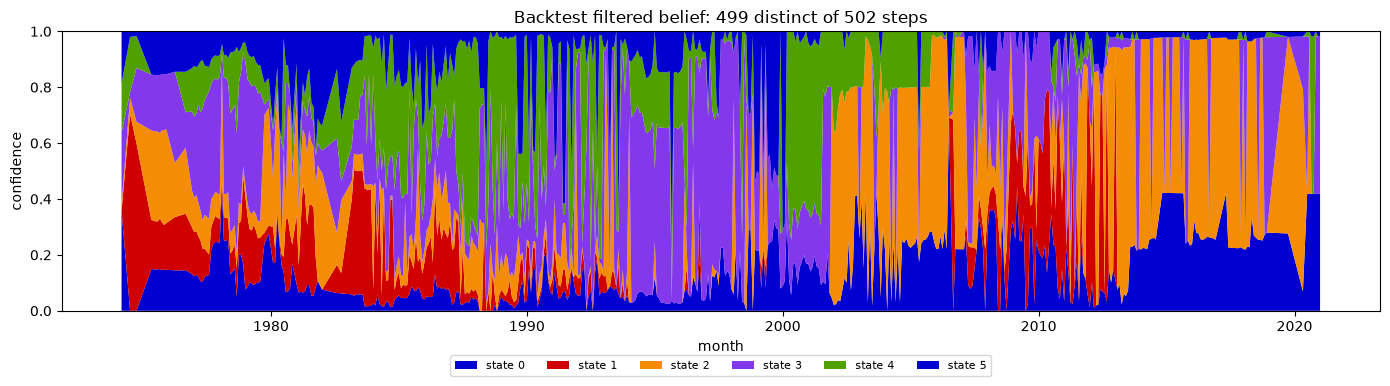

In [2]:
filtered = pplot.load_filtered_state_probs()
filtered_values = filtered.to_numpy(dtype=float)
n_steps = len(filtered)
n_distinct_filtered = int(np.unique(filtered_values, axis=0).shape[0])
print(f"backtest filtered belief: {n_distinct_filtered} distinct rows of {n_steps} steps "
      f"({filtered.index.min().date()} -> {filtered.index.max().date()}), states {list(filtered.columns)}")
fig_filtered = pregime.plot_soft_confidences(
    filtered, title=f"Backtest filtered belief: {n_distinct_filtered} distinct of {n_steps} steps"
)


## The served posterior

The served nowcaster is fitted once on the dev history (to 2020-12, training targets to 2019-12
under the 12-month embargo) and scored on every month observed in all of its model columns.


served posterior: 1 distinct of 233 complete months (2007-04-30 -> 2026-08-31), classes [0, 3, 4]
the posterior every month: {0: 0.418, 3: 0.564, 4: 0.018}


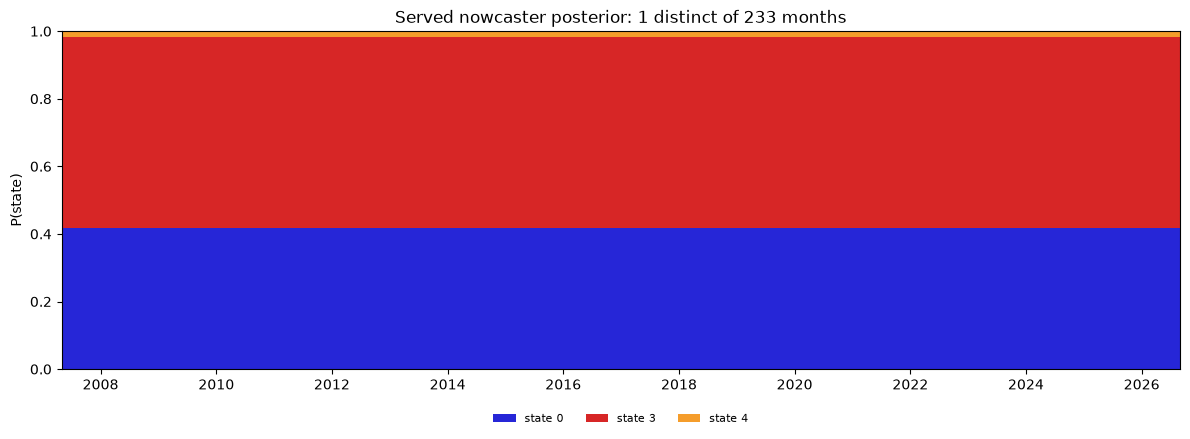

In [3]:
scratch = pplot.NOTEBOOK_SCRATCH_DIR / "p8"
shutil.rmtree(scratch, ignore_errors=True)
with contextlib.redirect_stdout(io.StringIO()):  # the builder prints absolute artifact paths
    served_cm = serving.build_scratch_serving(cfg, scratch)
dates, proba, classes = weekly.served_posterior_path(served_cm)
n_distinct_served = int(np.unique(proba, axis=0).shape[0])
print(f"served posterior: {n_distinct_served} distinct of {len(dates)} complete months "
      f"({dates.min().date()} -> {dates.max().date()}), classes {classes}")
print("the posterior every month:", {c: round(float(p), 4) for c, p in zip(classes, proba[0])})
fig_served = pnowcaster.plot_proba_over_time(
    dates, proba, classes,
    title=f"Served nowcaster posterior: {n_distinct_served} distinct of {len(dates)} months",
)
assert total_trial_count() == trials_before, "a registry row was appended"


## Why the page suspends the regime view (D-03)

The backtest's belief is a live object: hundreds of distinct rows, because each step refits on the
data it had. The served posterior is not: it is the **same vector every month**, whatever the
features say, and it covers only three of the regimes (the model's feature block starts in 2007,
so its training rows saw only those classes). Filtering a constant posterior gives a belief that
drifts to a fixed point; it carries no information about this month.

So the weekly page does not present a regime distribution, belief or posture. It trades the
measured no-regime ablation leg (A-13) and prints one status line. Fixing the served model (a
long-history feature set, a distinct-output check) is the first job of the regime-rebuild phase.


## N6 Sign-Off

Glenn fills this in after reading the notebook top to bottom (D-15 style: a plain cell, no helper,
no ledger).

**Date:** _pending_

**Verdict:** _pending_ (approve / approve with notes / reject)

**Reasoning:** _pending_
